In [1]:
from scripts.data_processing import download_all
download_all("1_cell_decrease_2_sigma/")

scp: /home/mameen/1_cell_decrease_2_sigma/019/errors.txt: No such file or directory
scp: /home/mameen/1_cell_decrease_2_sigma/024/errors.txt: No such file or directory
scp: /home/mameen/1_cell_decrease_2_sigma/051/errors.txt: No such file or directory
scp: /home/mameen/1_cell_decrease_2_sigma/066/errors.txt: No such file or directory
scp: /home/mameen/1_cell_decrease_2_sigma/076/errors.txt: No such file or directory
scp: /home/mameen/1_cell_decrease_2_sigma/081/errors.txt: No such file or directory


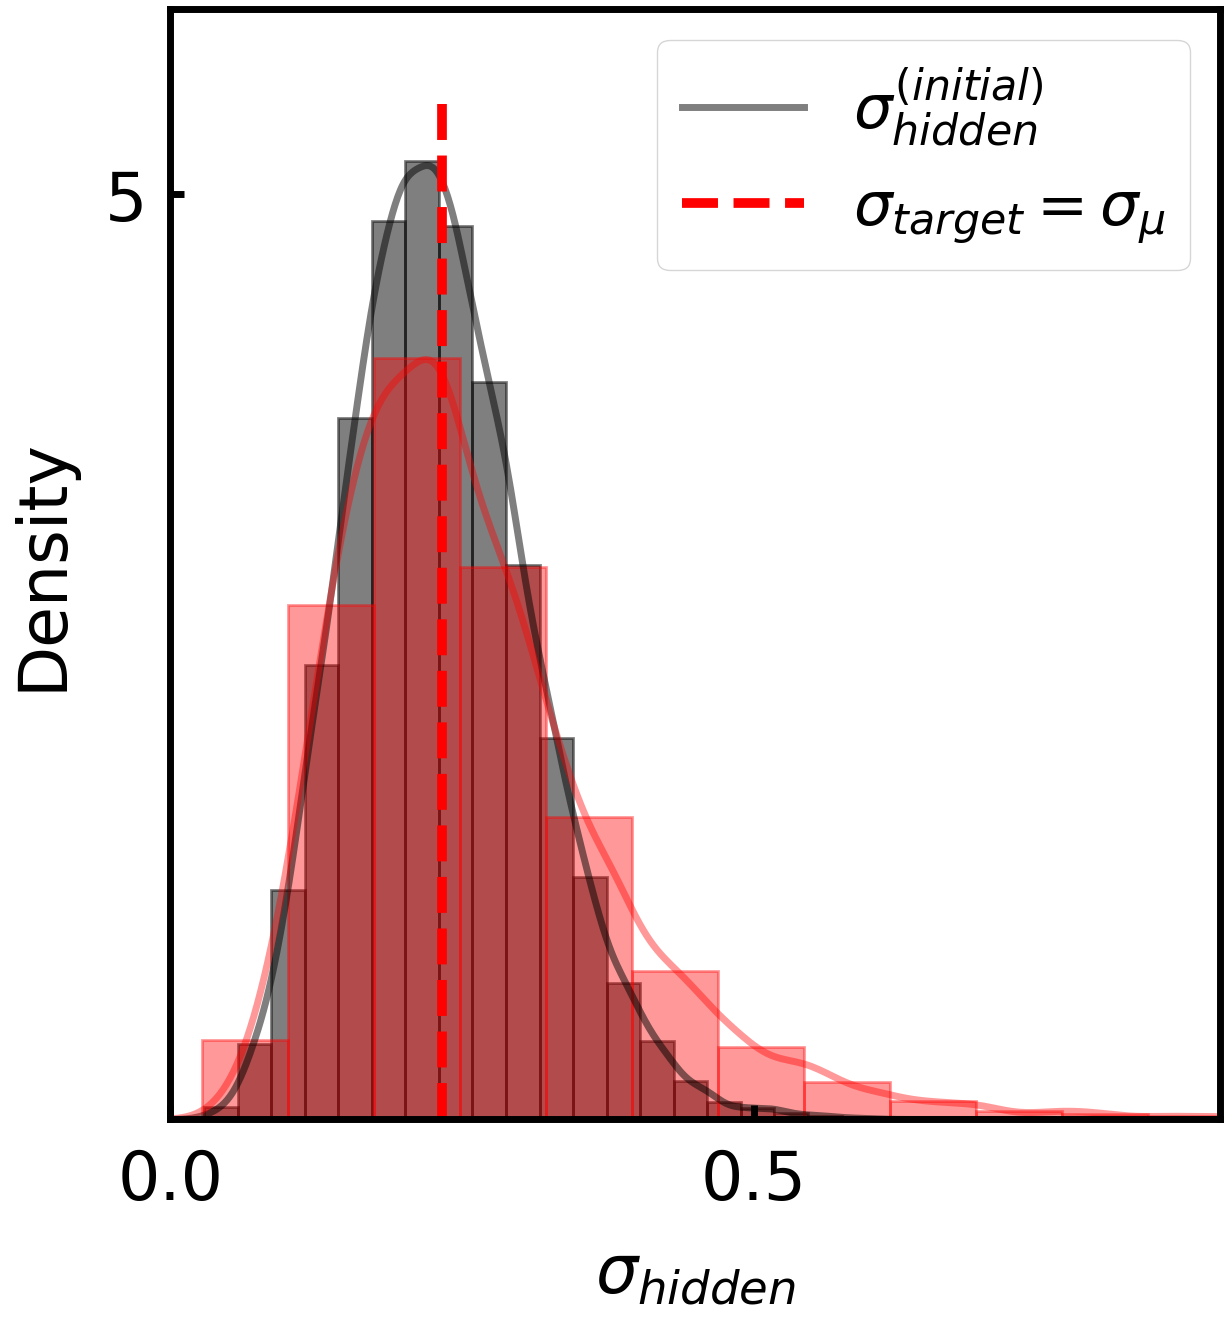

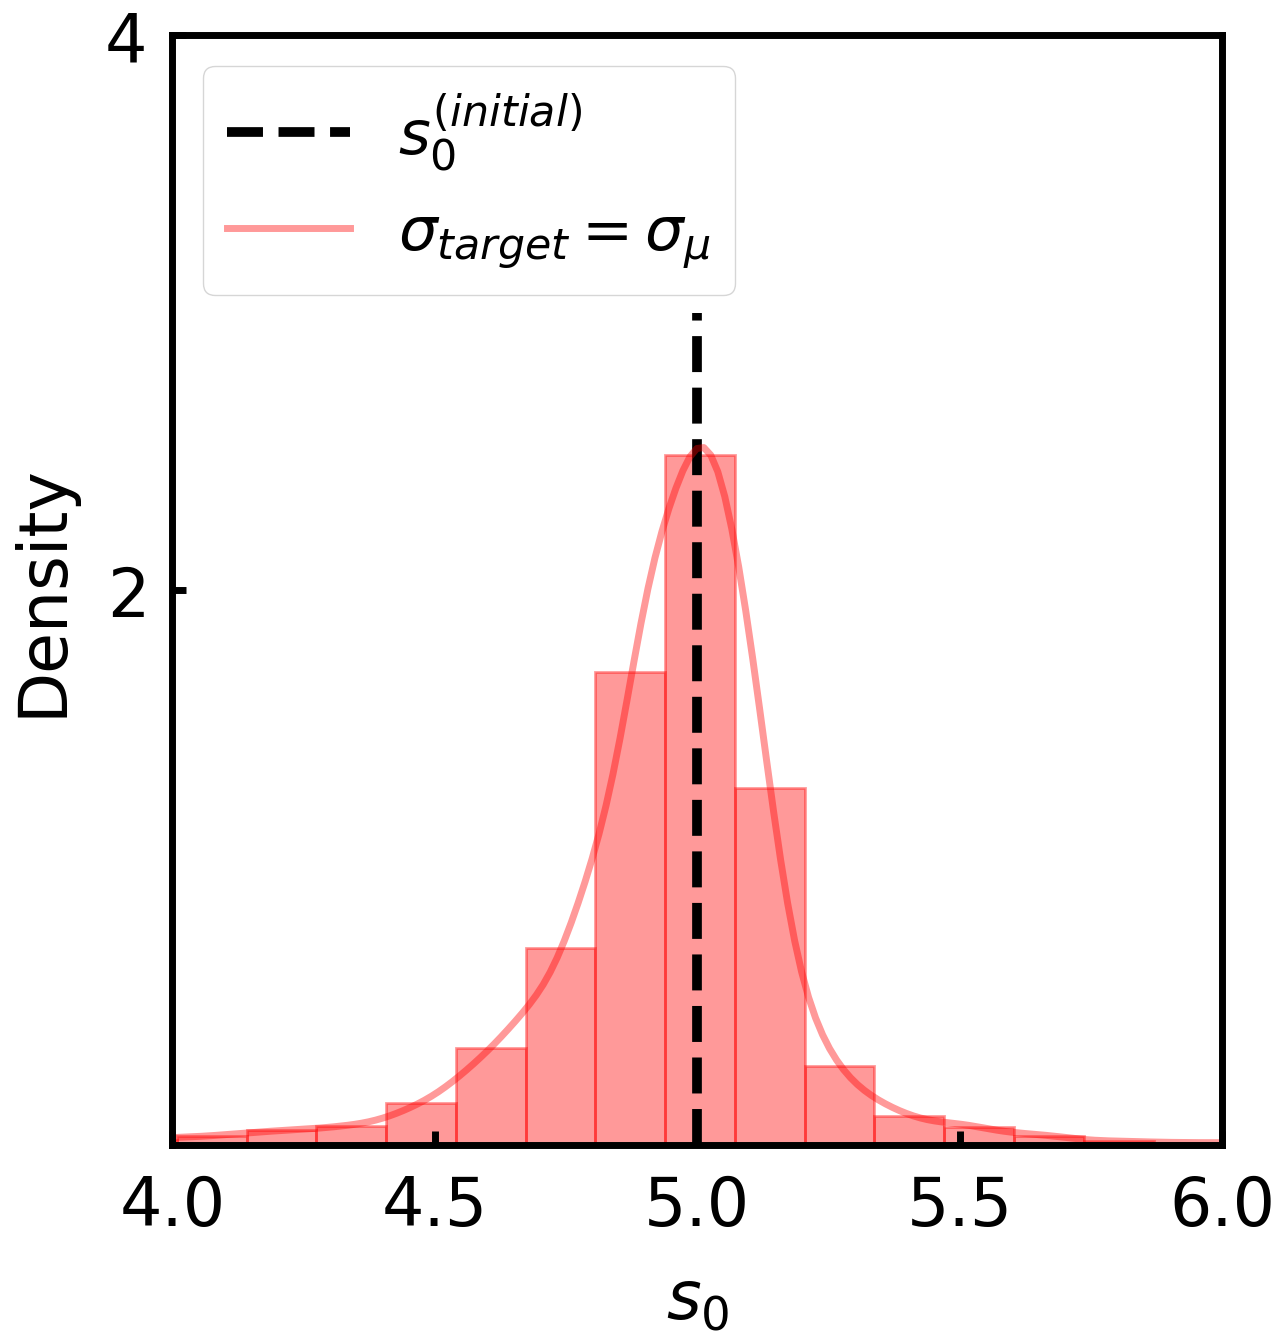

In [3]:
from scripts.plotgenerator import *
import numpy as np
dir="data/2_cells_mean/"
fname = "2_cells"
n_cells_stress_histogram(np.loadtxt("data_6/stresses.txt"), dir, filename = "{}_stress_histogram.jpg".format(fname))
n_cells_s0_histogram(dir, filename = "{}_s0_histogram.jpg".format(fname))


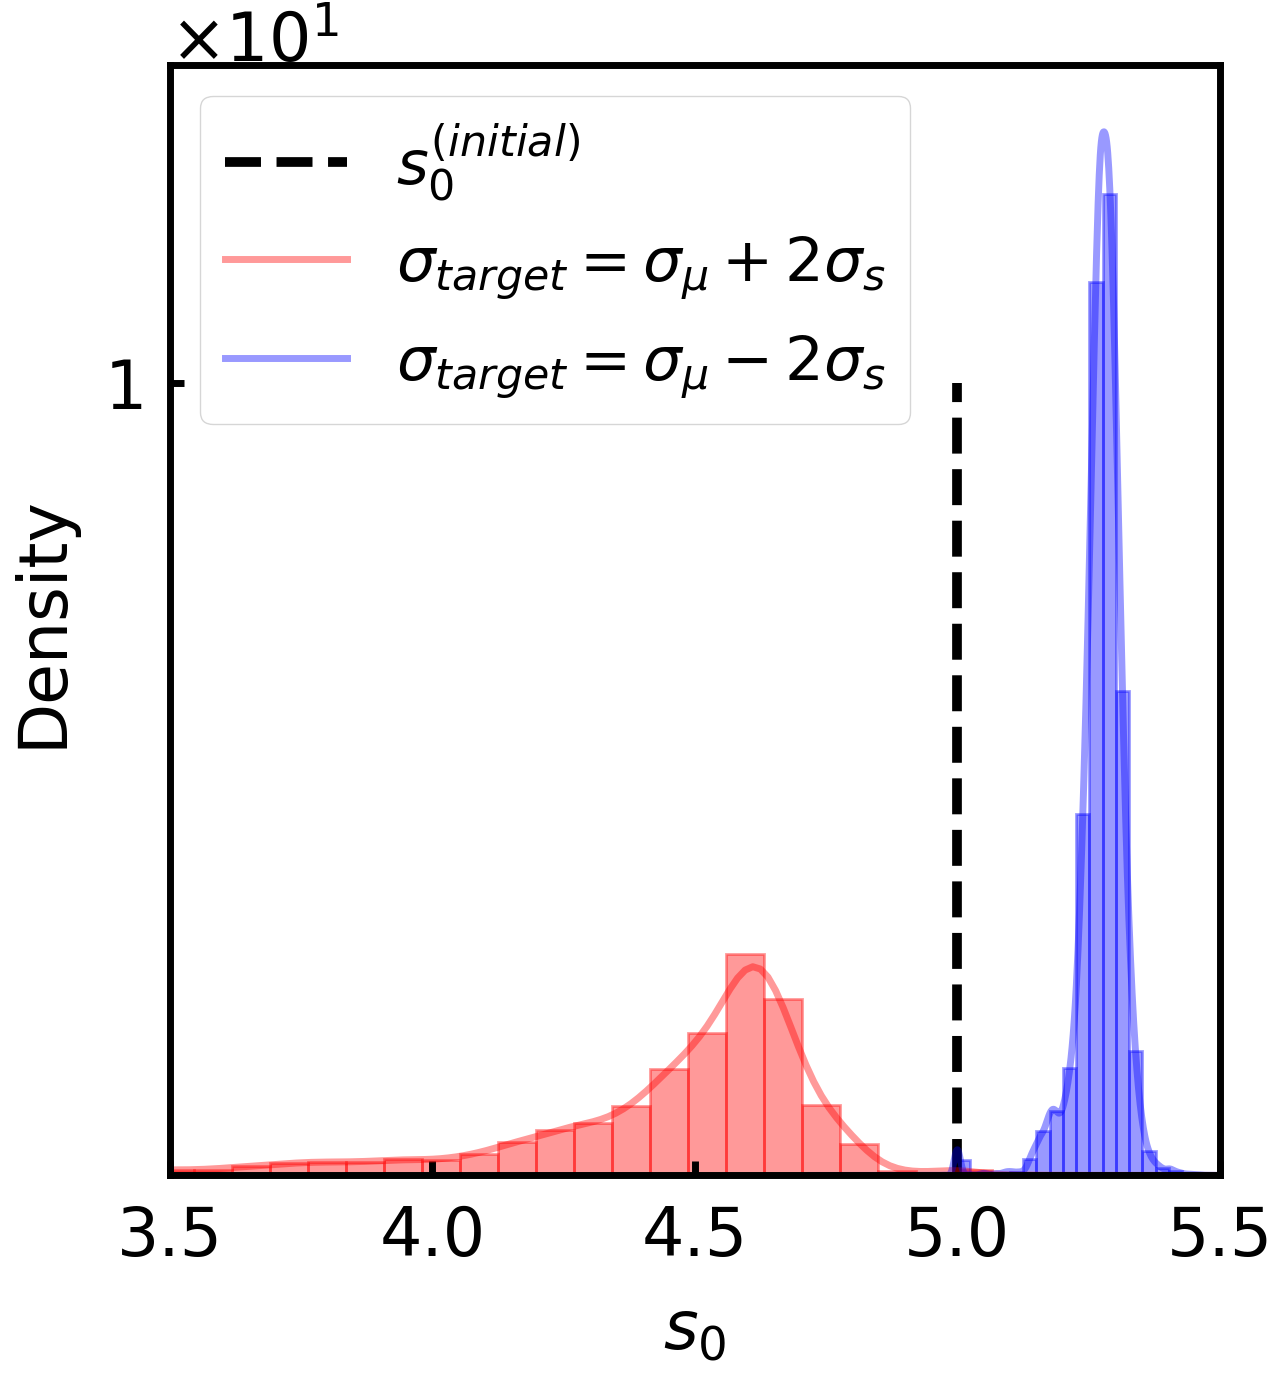

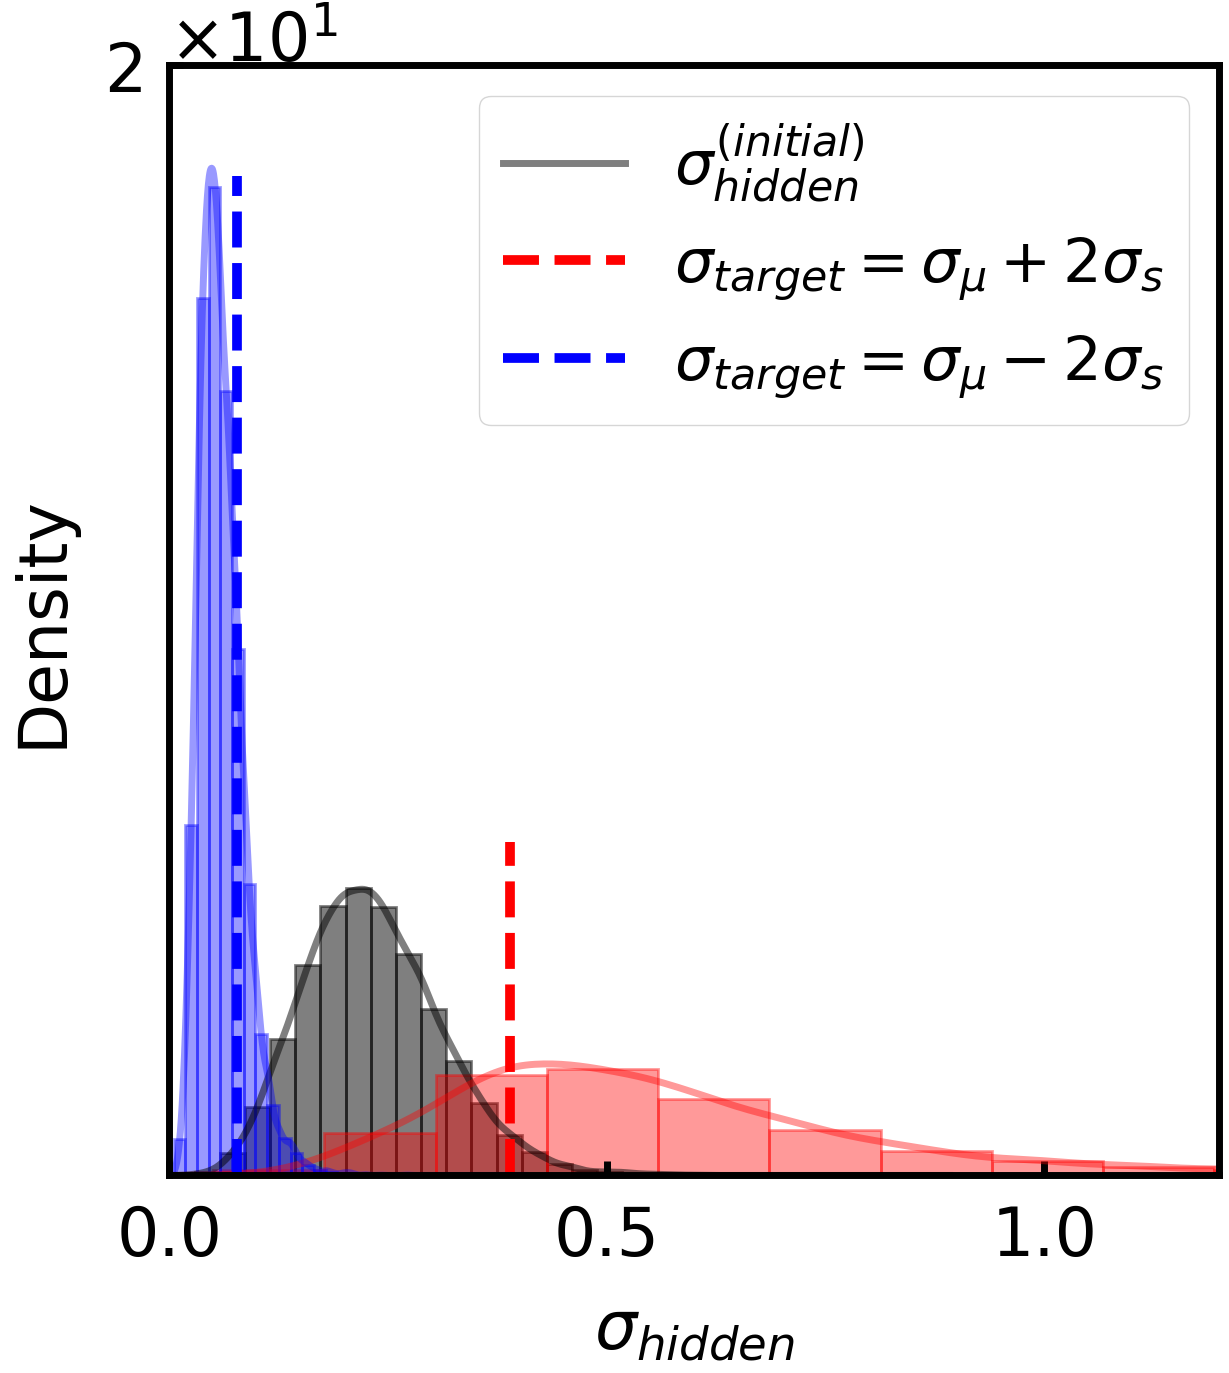

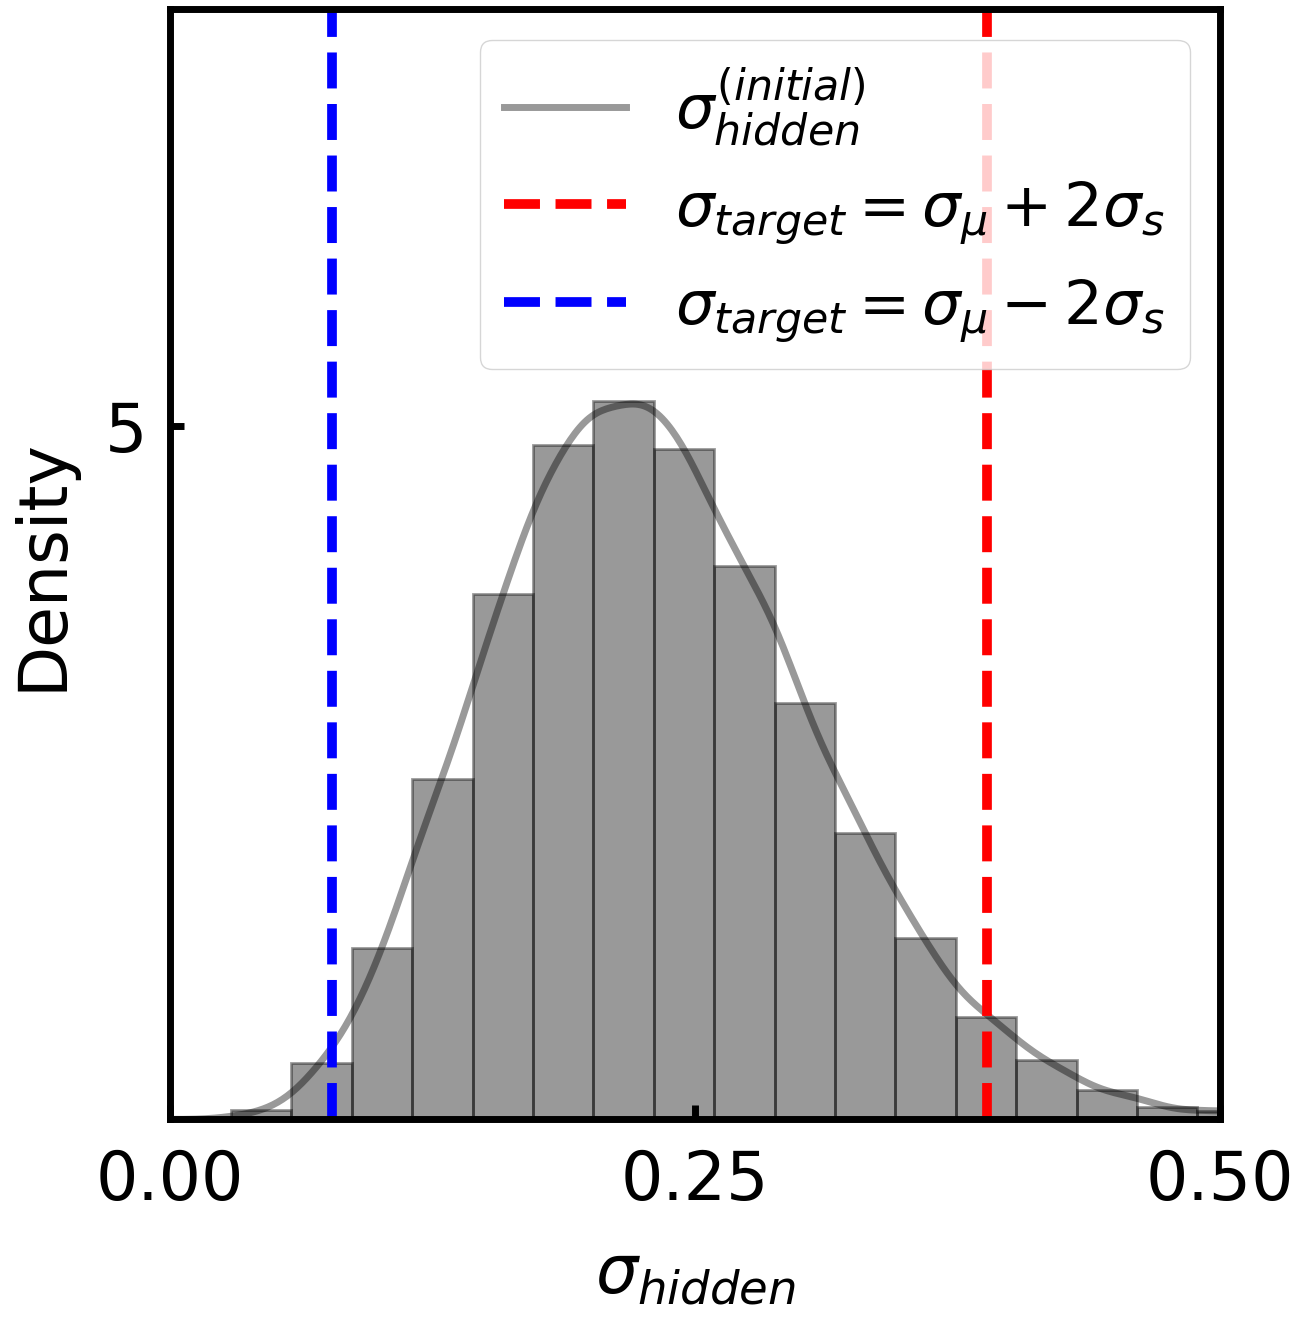

In [1]:
from scripts.plotgenerator import *
import numpy as np
inc_dir="data_6/1_cell_increase_2_sigma/"
dec_dir="data_6/1_cell_decrease_2_sigma/"

single_cell_combined_s0_histogram(inc_dir=inc_dir, dec_dir=dec_dir)
single_cell_combined_stress_histogram(init_stresses = np.loadtxt("data_6/stresses.txt") , inc_dir=inc_dir, dec_dir=dec_dir)
single_cell_initial_stress_histogram(array = np.loadtxt("data_6/stresses.txt"))

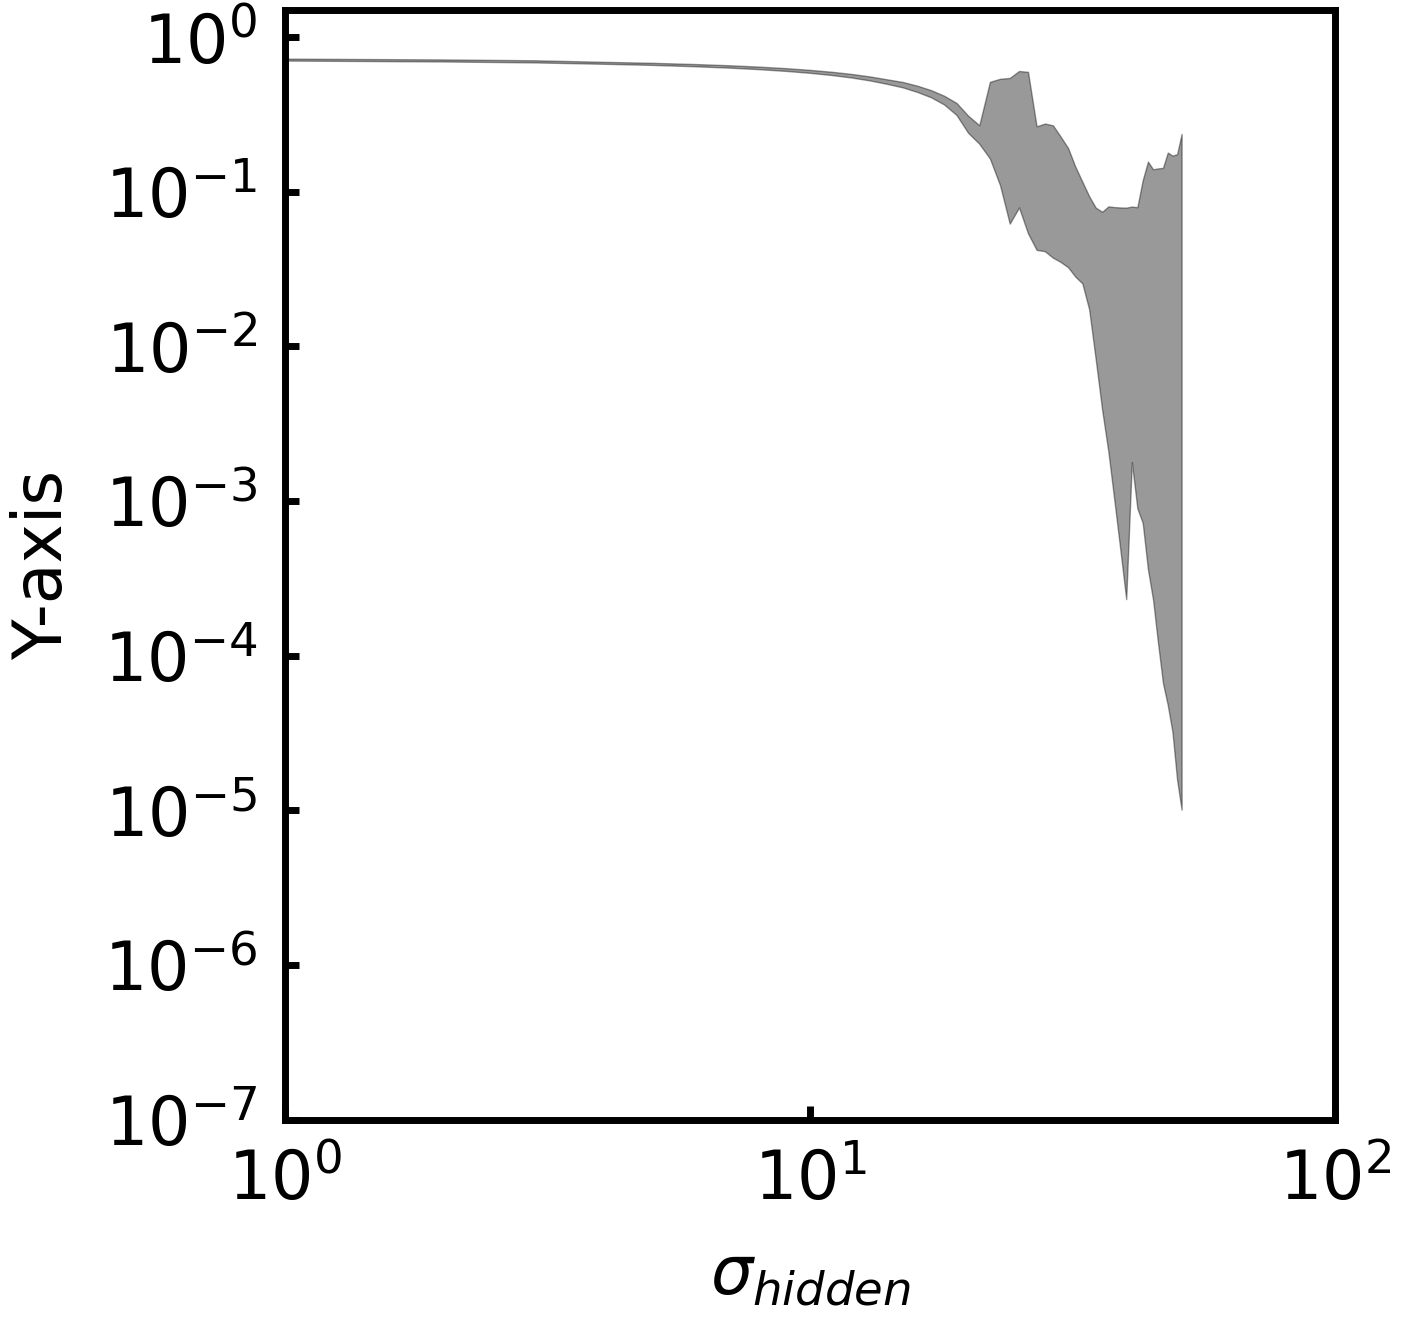

In [16]:
import numpy as np
import os
import pandas as pd
import scipy.stats as stats
from toolbox import manuscriptPlots

def mean_sem_by_index_fast(arrs_dict, min_count=3, ddof=1, drop_insufficient=True):
    wide = pd.DataFrame({k: pd.Series(v) for k, v in arrs_dict.items()})
    counts = wide.count(axis=1)
    means  = wide.mean(axis=1)
    stds   = wide.std(axis=1, ddof=ddof)              # ignores NaNs
    sems   = stds / np.sqrt(counts)
    need   = max(min_count, ddof + 1)
    sems[counts < need] = np.nan
    out = pd.DataFrame({"mean": means, "sem": sems})
    if drop_insufficient:
        out = out[counts >= need]
    out.index.name = "n"
    return out
source_to_target_decrease = {}
for i in range(10):
    dir = "data/1_cell_decrease_2_sigma/{:03d}/".format(i)
    if os.path.isfile(dir+"errors.txt"):
        source_to_target_decrease[dir] = np.loadtxt(dir+"errors.txt")
df_decrease = mean_sem_by_index_fast(source_to_target_decrease)

plotter = manuscriptPlots.plot()
plotter.set_ylim(1e-7,1.5)
plotter.set_xlim(1,100)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([5*i for i in range(1,100)])
plotter.set_xlabel(r"$\sigma_{hidden}$")
plotter.set_yScaled()
plotter.initialize_figure()
x_array = [i+1 for i in range(len(df_decrease["mean"].to_numpy()))]
plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")

# mean = np.mean(array)
# std = np.std(array)
# plotter.ax.vlines(mean+2*std, ymin = 0, ymax = 4,linestyles= "--", color = "red",alpha = 1,label = r"$\sigma_{target} = \sigma_\mu+2\sigma_s$")
# plotter.ax.vlines(mean-2*std, ymin = 0, ymax = 4,linestyles= "--", color = "blue",alpha = 1,label = r"$\sigma_{target} = \sigma_\mu-2\sigma_s$")
# plotter.ax.legend(loc='upper right')
# plotter.save_fig("graphs/{}".format(filename))


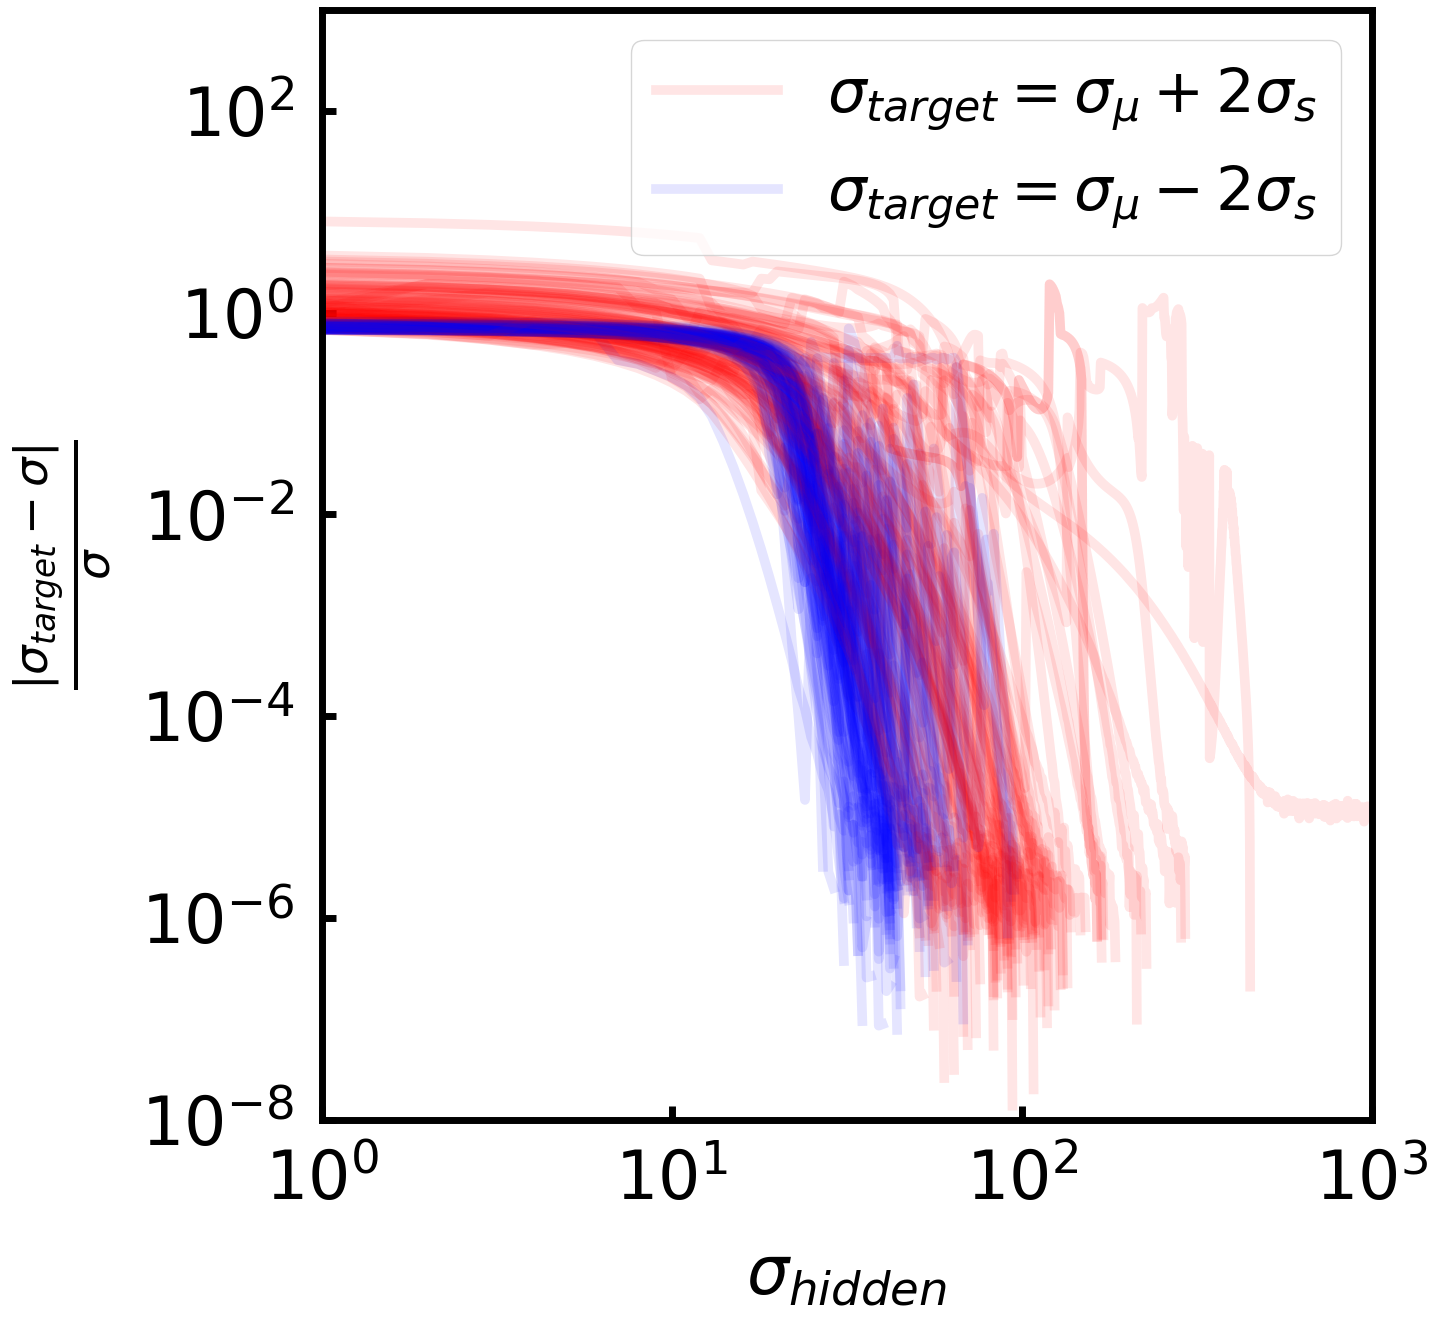

In [ ]:
## single cell, errors for all runs
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(1e-8,1e3)
plotter.set_xlim(1,1000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([5*i for i in range(1,100)])
plotter.set_xlabel(r"$\sigma_{hidden}$")
plotter.set_ylabel(r"$\frac{|\sigma_{target}-\sigma|}{\sigma}$")

plotter.set_yScaled()
plotter.initialize_figure()
for i in range(100):
    
    dir = "data/1_cell_increase_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt(dir+"errors.txt")
    x_array = [i+1 for i in range(len(errors))]
    plotter.plot_xy(x_array, errors, color ="red", alpha = 0.1,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, errors, color ="red", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu + 2\sigma_s$")


    dir = "data/1_cell_decrease_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt(dir+"errors.txt")
    x_array = [i+1 for i in range(len(errors))]
    plotter.plot_xy(x_array, errors, color ="blue", alpha = 0.1,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, errors, color ="blue", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu - 2\sigma_s$")
    

# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/single_cell_errors_all_runs.jpg")


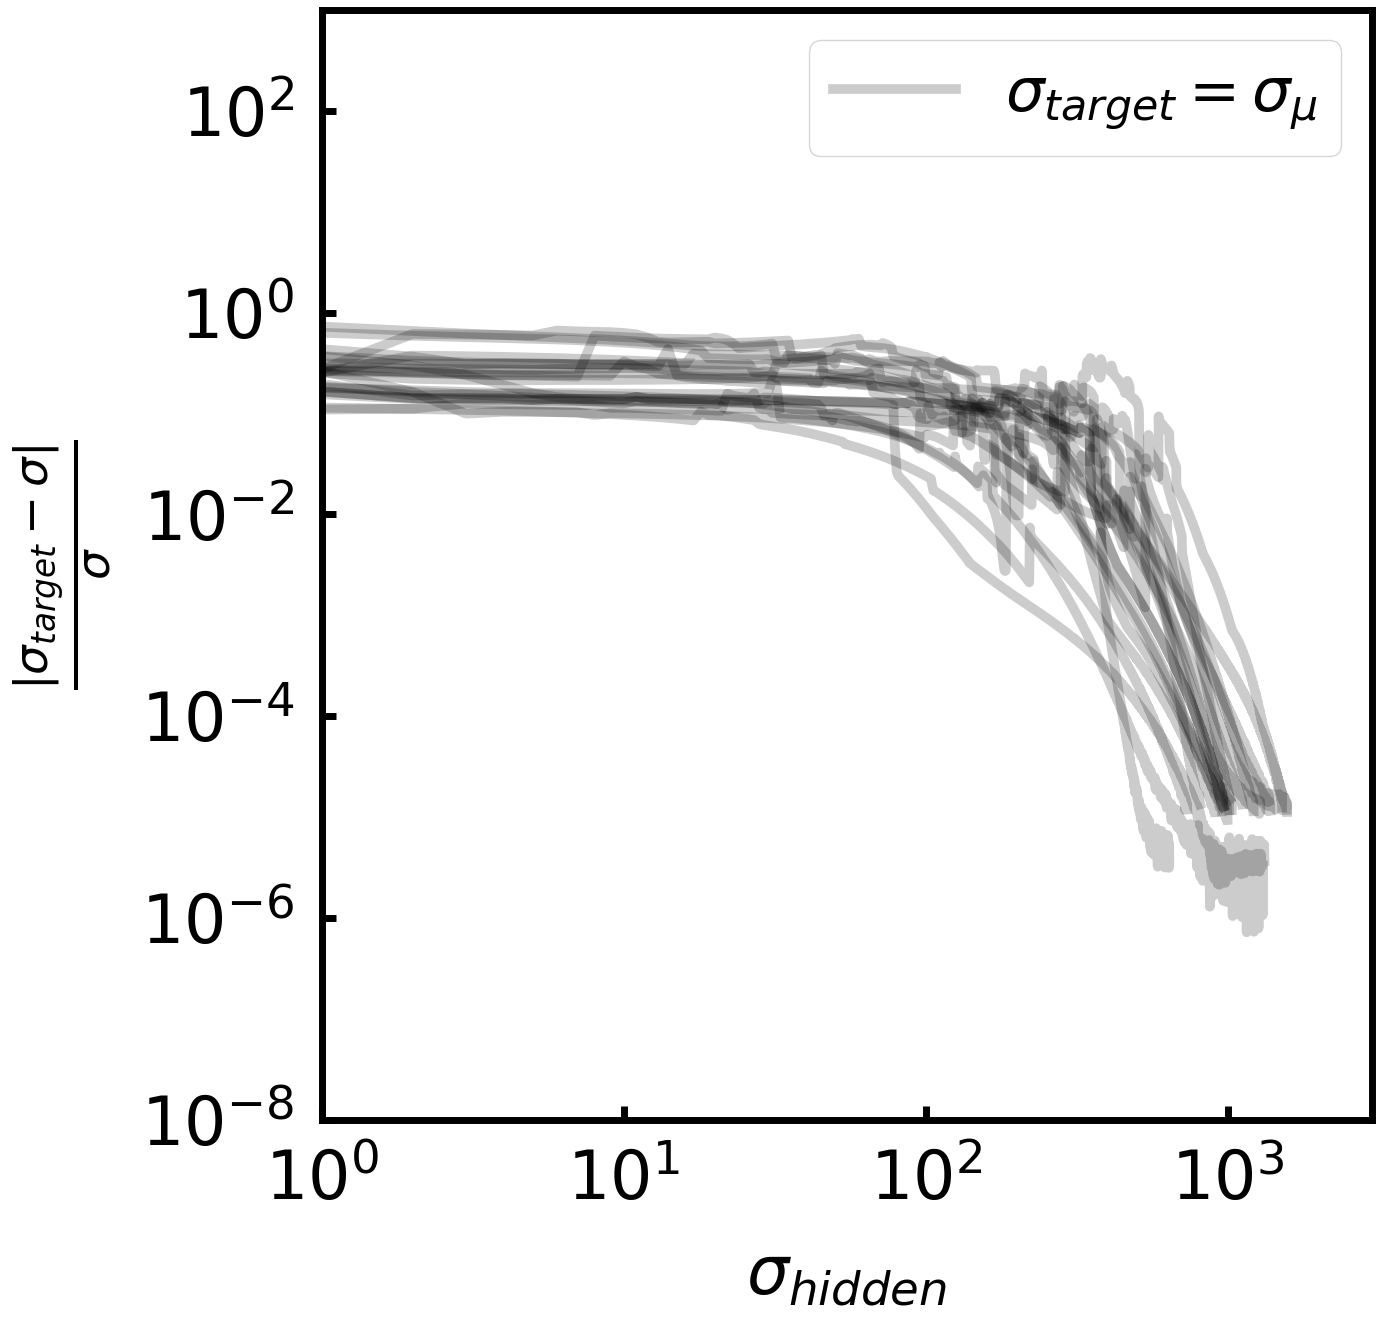

In [3]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(1e-8,1e3)
plotter.set_xlim(1,3000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([5*i for i in range(1,100)])
plotter.set_xlabel(r"$\sigma_{hidden}$")
plotter.set_ylabel(r"$\frac{|\sigma_{target}-\sigma|}{\sigma}$")

plotter.set_yScaled()
plotter.initialize_figure()
legend_added = False
for i in range(100):
    dir = "data/4_cells_mean/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt(dir+"errors.txt")
    x_array = [i+1 for i in range(len(errors))]
    plotter.plot_xy(x_array, errors, color ="black", alpha = 0.2,label = "_none")
    if legend_added:
        continue
    plotter.plot_xy(x_array, errors, color ="black", alpha = 0.2, label = r"$\sigma_{target}=\sigma_\mu$")
    legend_added = True


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/4_cells_errors_all_runs.jpg")


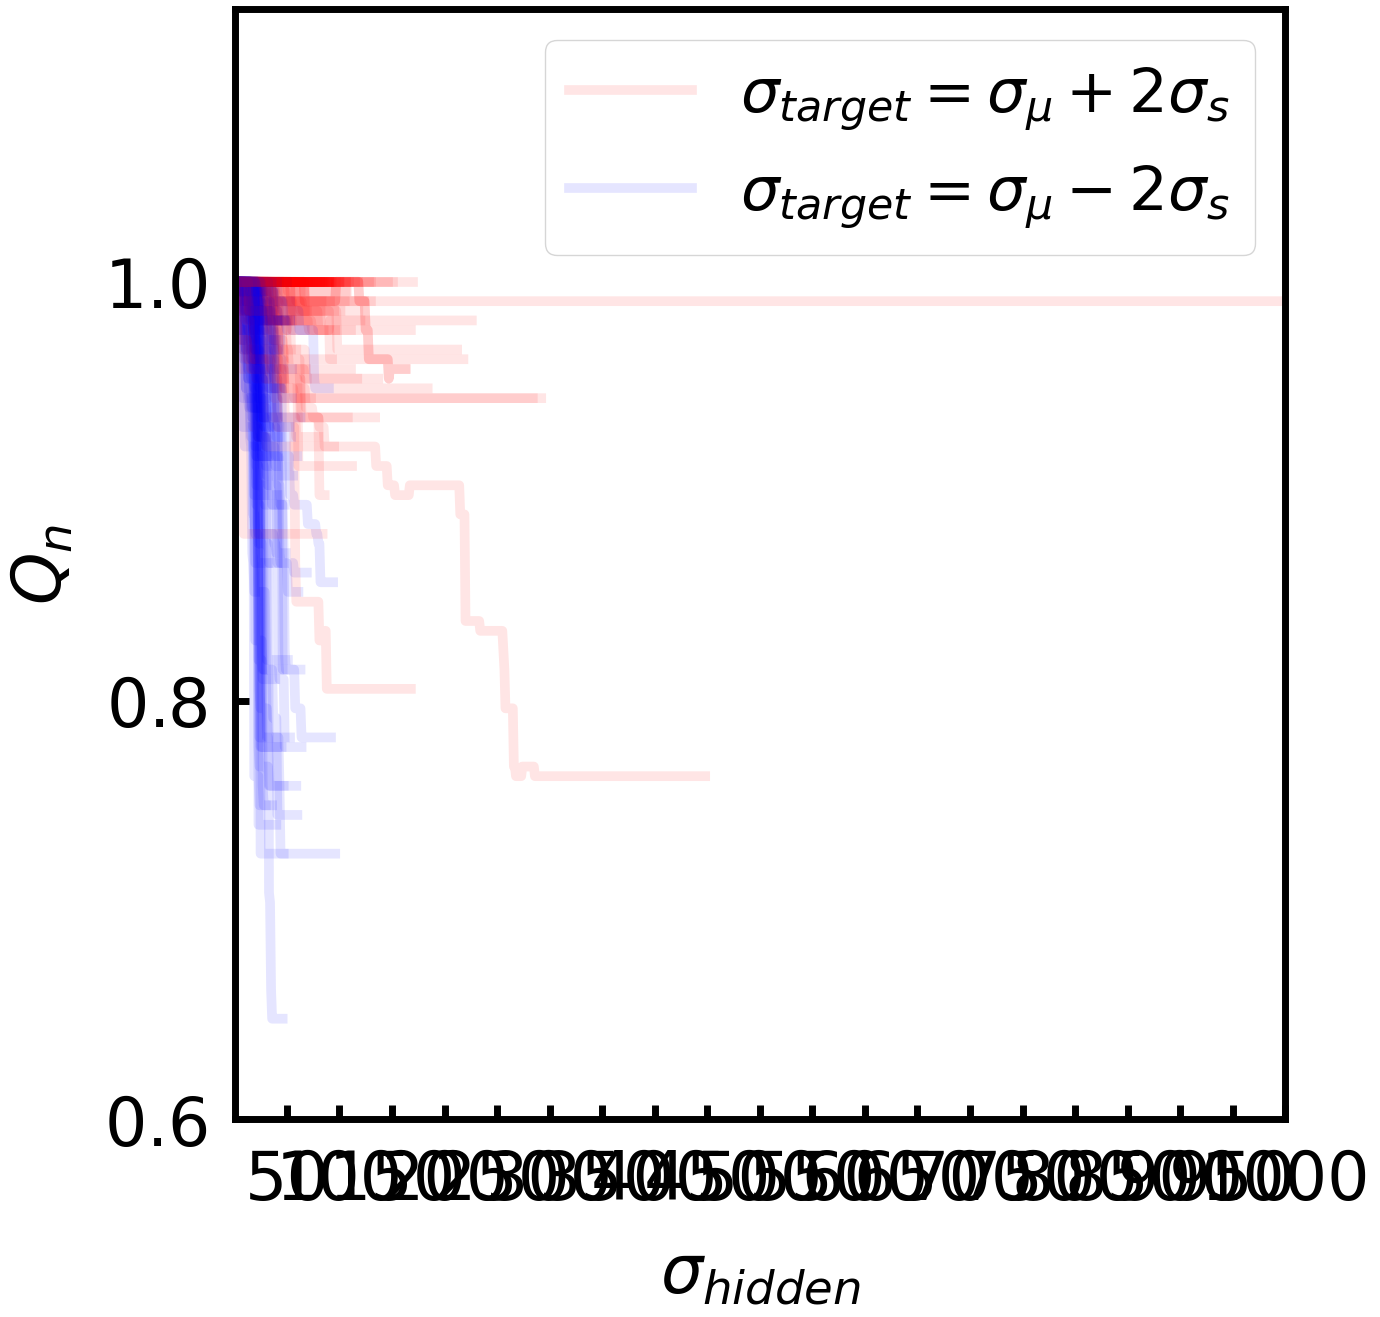

In [14]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(0.6,1.13)
plotter.set_xlim(1,1000)
plotter.set_xticks([50*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel(r"$\sigma_{hidden}$")
plotter.set_ylabel(r"$Q_n$")

plotter.set_yScaled()
plotter.initialize_figure()
for i in range(100):
    dir = "data/1_cell_increase_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    q_values = np.loadtxt(dir+"q_values.txt")
    # print(dir, errors[-1])
    x_array = [i+1 for i in range(len(q_values))]
    plotter.plot_xy(x_array, q_values, color ="red", alpha = 0.1,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, q_values, color ="red", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu + 2\sigma_s$")
    dir = "data/1_cell_decrease_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    q_values = np.loadtxt(dir+"q_values.txt")
    # print(dir, errors[-1])
    x_array = [i+1 for i in range(len(q_values))]
    plotter.plot_xy(x_array, q_values, color ="blue", alpha = 0.1,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, q_values, color ="blue", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu - 2\sigma_s$")


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
# plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/single_cell_overlap_all_runs.jpg")


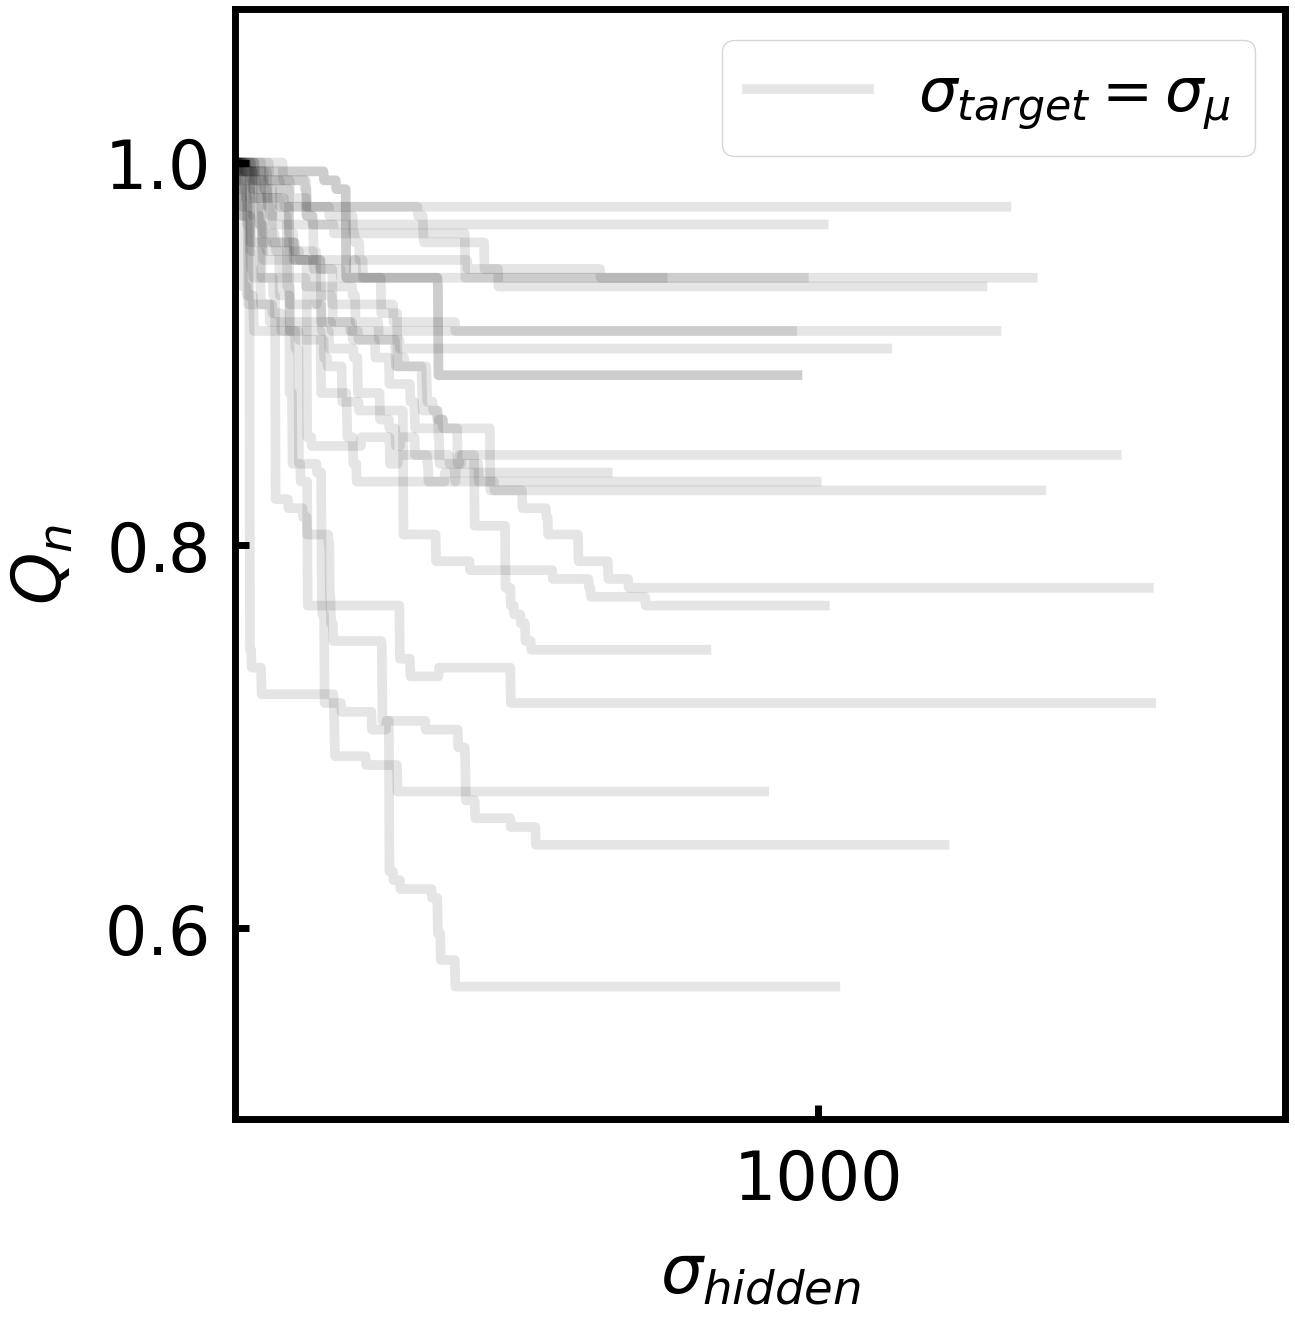

In [8]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(0.5,1.08)
plotter.set_xlim(1,1800)
plotter.set_xticks([1000*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel(r"$\sigma_{hidden}$")
plotter.set_ylabel(r"$Q_n$")

plotter.set_yScaled()
plotter.initialize_figure()
legend_added = False
for i in range(100):
    dir = "data/4_cells_mean/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    q_values = np.loadtxt(dir+"q_values.txt")
    # print(dir, errors[-1])
    x_array = [i+1 for i in range(len(q_values))]
    plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1,label = "_none")
    
    if legend_added:
        continue
    plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu$")
    legend_added = True
# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
# plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/4_cells_overlap_all_runs.jpg")
